# Analysis of False Primes #

$Author$: Michael Simons

$Class$: MTH 337 - Mathematical & Scientific Computing

$Date$: 09/9/22

## Introduction
Arguably the most fundamental idea in number theory is the concept of *prime numbers*. The set of primes contains every integer $N > 1$ , such that $N$'s only factors are 1 and itself. Any integer $N > 1$ that is **not** prime always has a prime factor. The complete factorization which consists only of prime numbers is known as $N$'s *primary decomposition* **:**     $60 = 2\times2\times3\times5$

Given two integers $P>0$ and $A$ from the interval $0\leq A<P$, the following property is always true when $P$ is a prime number:

$A^{P}(mod P) = A(mod P)$

Conversely, $A^{P}$ and $A$ are *congruent modulo* $P$. In the infrequent case that this property holds true for a number $P>0$ that is not prime, $P$ is a *false prime*.

This report will utilize the power of computation to analyze the primary decomposition of false prime numbers.

## Computing Prime Numbers
To find false primes and a number's *primary decomposition* requires a means of determining whether a number is prime or not. This can be done by iterating through the possible factors of $n$ and checking for divisibility. Once a factor is found, the number, $n$, will be determined non-prime. When the iteration reaches $\sqrt{n}$ and none have been found, all potential factors of $n$ have been eliminated and $n$ is determined prime.

In [1]:
#Boolean to determine if n is prine
def is_prime(n):
    if(n<2):return False               #Eliminate negatives,0,1 since they are non-prime
    for i in range(2,int(n**0.5)+1):   #Iterate through (excluding 1) until n's square root is reached
        if(n%i==0):return False        #Return false if a valid factor is found
    return True                        #Return true when options have been eliminated

To verify the correctness of the above function, it will be used to compute prime numbers $<11$

In [2]:
primes=[]
for i in range(0,11):#Test for primes<11
    if(is_prime(i)):primes.append(i)
print(primes)

[2, 3, 5, 7]


## Computing A Primary Decomposition
With the ability to compute prime numbers, computing a number's primary decomposition is simple. It will be done by simply iterating through potential factors of the number and accumulating a list of the valid prime factors. This list should represent the primary decomposition of the given number.

In [3]:
#Computes the primary decomposition of an integer n as a list representation
def primary_decomp(n):
    temp=n                                    #Local storage for n until completely factored
    comp=[]                                   #List to accumulate prime numbers
    while(temp>1):
        for i in range(2,int(temp)+1):        #Iterate through possible factors of n
            if(temp%i==0 and is_prime(i)):    #Verify the factor and that it is prime
                comp.append(i)                #Add the prime factor to the accumulating list
                temp=temp/i                   #Update temp with factored number and break the iteration
                break                                
    return comp                               #Return the accumulated list of prime numbers when the composition is complete

The function will now compute several primary decompositions as to verify correctness.

In [4]:
print("The primary decomposition of 15 is:",primary_decomp(15))
print("The primary decomposition of 56 is:",primary_decomp(56))
print("The primary decomposition of 100 is:",primary_decomp(100))
print("The primary decomposition of 100 is:",primary_decomp(67334))

The primary decomposition of 15 is: [3, 5]
The primary decomposition of 56 is: [2, 2, 2, 7]
The primary decomposition of 100 is: [2, 2, 5, 5]
The primary decomposition of 100 is: [2, 131, 257]


Our output consists only of prime numbers that produce the input. The function successfully computes the primary decomposition of a given integer.

## Identifying False Primes
Now that there are the necessary tools to analyze false primes, a means of computing them is required. As stated before, a false prime is a number $P$ such that for all $A$ where  $0\leq A<P$, $A^{P}$ and $A$ are congruent modulo $P$, but $P$ is not prime. To determine whether a number is a false prime, we will first write a function to determine whether this congruence property holds true for a given number.

In [5]:
#Boolean to determine whether the prime-like congruence holds for the given number
def is_prime_like(p):
    if(p<2):return False
    for a in range(0,p):                  #Verify the congruence modulo for all values of A
        if(pow(a,p,p)!=a%p):return False  #Return false if the congruence relation doesn't hold true.
    return True                           #Use of pow is more efficient than (A**P)%K, due to pythonic reasons

With the above mechanism to verify the congruence relation, we can now easily write a function to determine whether a number is false prime. Given an integer, if the condition true then our previous function can be called to check if the number is prime or not. If the integer isn't a prime, then it is a false prime and the function should return true.

In [6]:
#Boolean to determine whether the given number is a false prime
def is_false_prime(p):
    if(is_prime_like(p)):        #Verify the prime-like congruence
        return (not is_prime(p)) #Returns true if it isn't prime but has the congruence property
    return False

## Computing Primary Decompositions Of False Primes

We now have a method of identifying false primes and it will be used to compute the first 40 of them. Included in the computation will be the primary decomposition of each false prime.

In [7]:
import time
false_primes=[]
primary_decomps=[]
i=2
start_time = time.time()
while(len(false_primes)<40):
    if(is_false_prime(i)):
        false_primes.append(i)
        primary_decomps.append(primary_decomp(i))
    i+=1
end_time = time.time()
elapsed_time = end_time - start_time
print(f'40 False Primes were Computed in {elapsed_time:.4f} seconds')

40 False Primes were Computed in 28065.3227 seconds


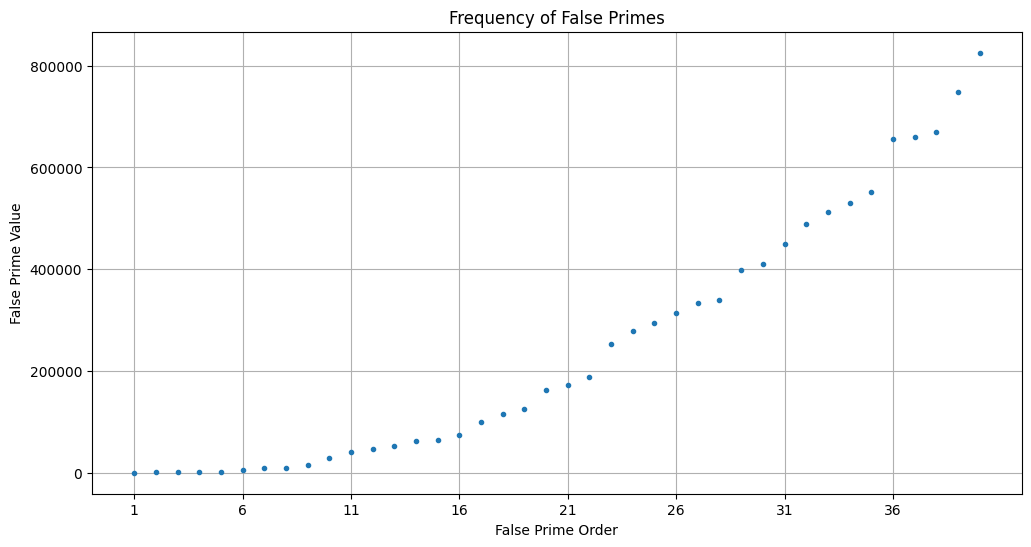

In [12]:
import matplotlib.pyplot as plt
from collections import Counter

plt.figure(figsize=(12, 6)) 
plt.plot([i for i in range(1, len(false_primes) + 1)], false_primes, '.')

# Set x-ticks with a larger gap
plt.xticks([i for i in range(1, len(false_primes) + 1, 5)])

plt.xlabel("False Prime Order")
plt.ylabel("False Prime Value")
plt.title("Frequency of False Primes")
plt.grid(True)
plt.show()

In [9]:
for i in range(0,len(false_primes)):
    print(f'Primary Decomposition of {false_primes[i]}: {primary_decomps[i]}')

Primary Decomposition of 561: [3, 11, 17]
Primary Decomposition of 1105: [5, 13, 17]
Primary Decomposition of 1729: [7, 13, 19]
Primary Decomposition of 2465: [5, 17, 29]
Primary Decomposition of 2821: [7, 13, 31]
Primary Decomposition of 6601: [7, 23, 41]
Primary Decomposition of 8911: [7, 19, 67]
Primary Decomposition of 10585: [5, 29, 73]
Primary Decomposition of 15841: [7, 31, 73]
Primary Decomposition of 29341: [13, 37, 61]
Primary Decomposition of 41041: [7, 11, 13, 41]
Primary Decomposition of 46657: [13, 37, 97]
Primary Decomposition of 52633: [7, 73, 103]
Primary Decomposition of 62745: [3, 5, 47, 89]
Primary Decomposition of 63973: [7, 13, 19, 37]
Primary Decomposition of 75361: [11, 13, 17, 31]
Primary Decomposition of 101101: [7, 11, 13, 101]
Primary Decomposition of 115921: [13, 37, 241]
Primary Decomposition of 126217: [7, 13, 19, 73]
Primary Decomposition of 162401: [17, 41, 233]
Primary Decomposition of 172081: [7, 13, 31, 61]
Primary Decomposition of 188461: [7, 13, 19

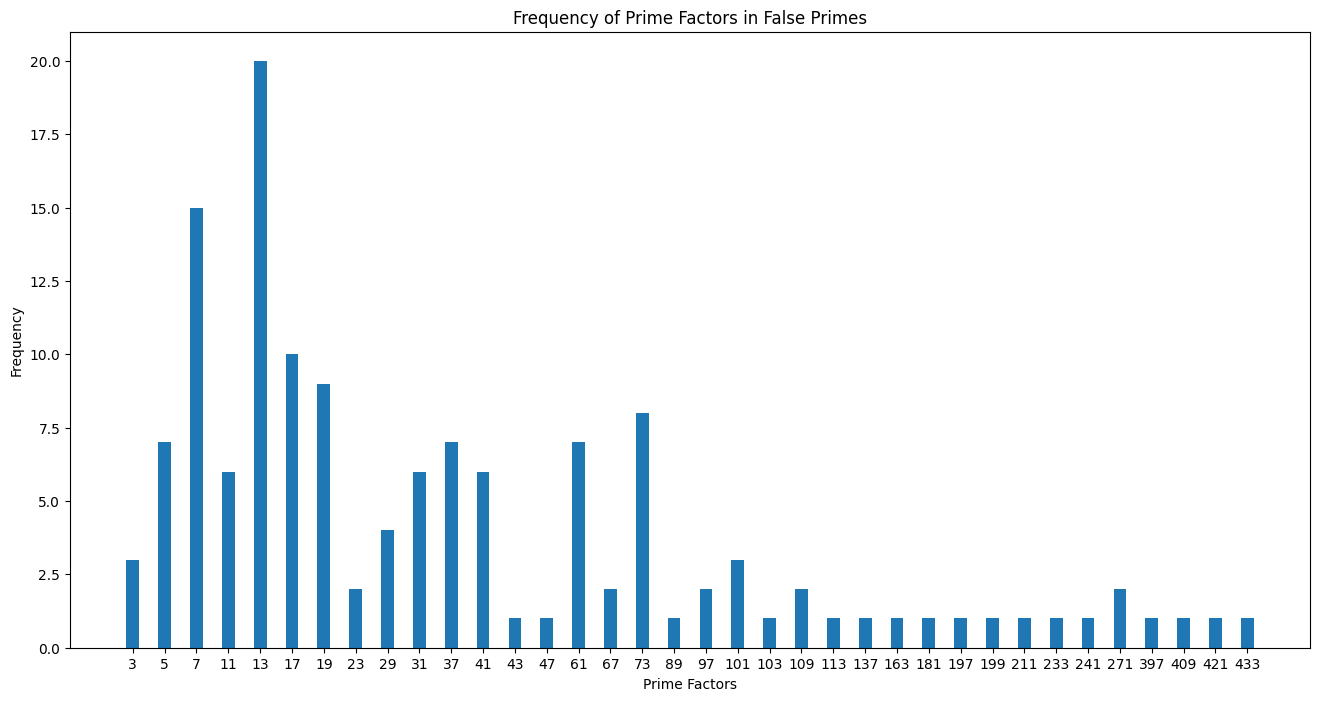

In [29]:
plt.figure(figsize=(16, 8))

# Get the keys (prime factors) and values (frequencies)
x_ticks = list(prime_counts.keys())
y_values = list(prime_counts.values())

# Sort the prime factors and their corresponding frequencies
sorted_primes = sorted(x_ticks)
sorted_frequencies = [prime_counts[prime] for prime in sorted_primes]

# Set bar width and spacing
bar_width = 0.5 
spacing = 0.75 

# Calculate positions for the bars
x_positions = [i * (bar_width + spacing) for i in range(len(sorted_primes))]

# Plot the bar chart
plt.bar(x_positions, sorted_frequencies, width=bar_width)

# Set the x-ticks to match the positions of the bars
plt.xticks(x_positions, sorted_primes)

# Label the axes and set the title
plt.xlabel("Prime Factors")
plt.ylabel("Frequency")
plt.title("Frequency of Prime Factors in False Primes")

# Show the plot
plt.show()

## Conclusion
We note that it took over 7.7 hours (28065.3227 seconds) to compute the first 40 false primes using our naive algorithm. From our results, we observe that the interval in which false primes were computed seemed to widen exponentially as the numbers became larger. There is a clear and drastic relation between the frequency in which false primes occur and how many have already been found.

The graph titled “Frequency of Prime Factors in False Primes” shows a clear trend of increasing frequency for most prime factors as the false primes increase in magnitude. Smaller prime factors, such as 3, 5, and 7, appear in a much larger number of the first 40 false primes. Larger prime factors, such as 101, 103, and 113, appear in very few of the first 40 false primes. This can be attributed to the nature of false primes: they are composite numbers with a prime-like congruence property. This property suggests that they have a more restricted set of divisors. As the false primes get larger, their primary decompositions become more complex, increasing the likelihood of including smaller primes as factors. This explains the greater frequency of smaller primes in the decompositions of larger false primes. The graph highlights the relationship between the size of false primes and the frequency of their prime factors.

False primes are just one of many topics in the field of prime numbers that computation can help us understand. Overall, the exploration of prime numbers is important, and an excellent demonstration of how powerful of a tool computation can be in mathematical research.